# MapReduce模式
大数据处理
> google提出，MapReduce是一种分布式计算模型，用于处理大规模数据集的并行计算。
> 它的核心思想是将计算任务分成两个阶段：Map阶段和Reduce阶段。-- 分而治之


* 优点：
    * 自动并行化：开发者只需要写 Map 和 Reduce 函数，不需要关心分布式调度。
    * 高容错性：MapReduce系统具有高容错性，即使某些机器失败，计算任务也可以在其他机器上继续执行。
    * 高可扩展性：MapReduce系统可以很容易地扩展到更多的机器上，处理更大的数据集。

所以，非常适合可分解成独立子任务且最终结果可以合并的场景。

## Langgraph 实现

In [1]:
from typing import Annotated, List, Any
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.constants import Send
import operator
import re

# 定义整体状态结构体
class OverallState(TypedDict):
    # 原始大规模输入数据
    large_input_data: List[str]
    # 分割后的子数据集
    sub_datasets: List[List[str]]
    # Map 阶段的处理结果 (使用 operator.add Reducer 收集结果)
    intermediate_results: Annotated[List[dict], operator.add]
    # Reduce 阶段的最终结果
    final_result: dict

# 定义 Map 节点的私有状态结构体
class MapState(TypedDict):
    sub_data: Any  # 子任务数据类型可以是任意类型

def split_large_data(input_data: List[str], num_sub_tasks: int = 10) -> List[List[str]]:
    """将大规模数据分割成子数据集"""
    chunk_size = max(1, len(input_data) // num_sub_tasks)
    chunks = []
    for i in range(0, len(input_data), chunk_size):
        chunks.append(input_data[i:i + chunk_size])
    return chunks

def split_input_data(state: OverallState):
    """分割节点函数：只负责数据分割，不返回 Send 对象"""
    input_data = state["large_input_data"]  # 从状态中获取大规模输入数据
    sub_datasets = split_large_data(input_data, num_sub_tasks=4)  # 将大规模数据分割成子数据集

    print(f"🔄 分割节点: 将 {len(input_data)} 个文档分割成 {len(sub_datasets)} 个子数据集")
    for i, sub_dataset in enumerate(sub_datasets):
        print(f"📦 子数据集 {i}: {len(sub_dataset)} 个文档")

    return {"sub_datasets": sub_datasets}

def route_to_map_nodes(state: OverallState):
    """路由函数：根据分割的数据创建 Send 对象"""
    sub_datasets = state["sub_datasets"]

    print(f"🔀 路由函数: 创建 {len(sub_datasets)} 个并行任务")

    send_list = []
    for i, sub_dataset in enumerate(sub_datasets):  # 遍历每个子数据集
        send_list.append(
            Send("map_node", {"sub_data": sub_dataset})  # 为每个子数据集创建一个 Send 对象
        )

    print(f"✅ 路由完成: 创建了 {len(send_list)} 个 Send 对象")
    return send_list  # 返回 Send 对象列表，用于动态路由到多个 Map 节点实例

def process_sub_data(sub_data: List[str]) -> dict:
    """处理子任务数据，生成中间结果"""
    word_count = {}
    total_chars = 0

    for doc in sub_data:
        # 统计词频
        words = re.findall(r'\b\w+\b', doc.lower())
        for word in words:
            word_count[word] = word_count.get(word, 0) + 1
        # 统计字符数
        total_chars += len(doc)

    return {
        "word_count": word_count,
        "doc_count": len(sub_data),
        "total_chars": total_chars,
        "unique_words": len(word_count)
    }

def map_node(state: MapState):
    """Map 节点函数，输入状态为 MapState"""
    sub_data = state["sub_data"]  # 从状态中获取子任务数据
    print(f"🔧 Map 节点: 开始处理 {len(sub_data)} 个文档")

    intermediate_result = process_sub_data(sub_data)  # 处理子任务数据，生成中间结果

    print(f"✅ Map 节点: 处理完成，找到 {intermediate_result['unique_words']}个不同单词")

    return {"intermediate_results": [intermediate_result]}  # 返回中间结果，用于后续 Reduce 阶段聚合

def aggregate_results(intermediate_results: List[dict]) -> dict:
    """聚合中间结果，生成最终结果"""
    global_word_count = {}
    total_docs = 0
    total_chars = 0

    for result in intermediate_results:
        total_docs += result["doc_count"]
        total_chars += result["total_chars"]

        # 合并词频统计
        for word, count in result["word_count"].items():
            global_word_count[word] = global_word_count.get(word, 0) + count

    # 找出最高频和最低频的词
    if global_word_count:
        sorted_words = sorted(global_word_count.items(), key=lambda x: x[1],
reverse=True)
        most_common = sorted_words[0]
        least_common = sorted_words[-1]
    else:
        most_common = ("", 0)
        least_common = ("", 0)

    return {
        "total_documents": total_docs,
        "total_characters": total_chars,
        "total_unique_words": len(global_word_count),
        "total_words": sum(global_word_count.values()),
        "most_common_word": most_common,
        "least_common_word": least_common,
        "word_distribution": dict(sorted_words[:10])  # 只保留前10个高频词
    }

def reduce_node(state: OverallState):
    """Reduce 节点函数，输入状态为 OverallState"""
    intermediate_results = state["intermediate_results"]  # 从状态中获取 Map 阶段生成的中间结果列表

    print(f"🔄 Reduce 节点: 汇聚 {len(intermediate_results)} 个中间结果")

    final_result = aggregate_results(intermediate_results)  # 聚合中间结果，生成最终结果

    print(f"✅ Reduce 完成: 汇总了 {final_result['total_documents']} 个文档")

    return {"final_result": final_result}  # 返回最终结果

# 构建 MapReduce 图
print("🏗️ 构建标准 MapReduce 图...")
builder = StateGraph(OverallState)

# 添加节点
builder.add_node("split_node", split_input_data)
builder.add_node("map_node", map_node)
builder.add_node("reduce_node", reduce_node)

# 连接 MapReduce 流程中的节点和边
builder.add_edge(START, "split_node")

# 关键修正：分离数据分割和任务路由
# 分割节点 -> Map 节点 (条件边, 使用专门的路由函数)
builder.add_conditional_edges("split_node", route_to_map_nodes, ["map_node"])

# Map 节点 -> Reduce 节点 (普通边)
builder.add_edge("map_node", "reduce_node")

# Reduce 节点 -> END (普通边)
builder.add_edge("reduce_node", END)

mapreduce_graph = builder.compile()
print("✅ 图构建完成！")

# 测试数据：模拟大规模文档数据
large_documents = [
    "LangGraph is a powerful framework for building AI agent systems with complex workflows.",
    "The framework provides comprehensive state management and advanced flow control capabilities.",
    "Parallel processing in LangGraph enables efficient task execution and resource utilization.",
    "MapReduce pattern helps process large datasets effectively using distributed computing principles.",
    "AI agents can use various tools and manage complex workflows with sophisticated coordination.",
    "State management is crucial for building reliable and scalable distributed systems.",
    "LangGraph supports dynamic branching with Send API for flexible workflowdesign.",
    "Concurrent execution improves overall system performance and throughput significantly.",
    "The Send API enables dynamic task distribution and parallel processing capabilities.",
    "Reducer functions ensure safe concurrent state updates in multi-threadedenvironments.",
    "Graph-based workflows provide clear visualization and better debugging capabilities.",
    "Advanced error handling and retry mechanisms ensure robust system operation."
]

print("\n=== 🚀 MapReduce 大规模文档处理演示 ===")
print(f"📄 输入文档数量: {len(large_documents)}")
print(f"📊 使用 Send API 实现动态任务分发")
print(f"🔄 MapReduce 流程: 分割 -> 并行映射 -> 归约")
print("\n" + "="*60)

# 执行 MapReduce 流程
result = mapreduce_graph.invoke({
    "large_input_data": large_documents,
    "sub_datasets": [],
    "intermediate_results": [],
    "final_result": {}
})

print("="*60)
print("\n=== ✨ MapReduce 处理结果 ===")
final_result = result["final_result"]
print(f"📊 总文档数: {final_result['total_documents']}")
print(f"📝 总字符数: {final_result['total_characters']}")
print(f"🔤 不同单词数: {final_result['total_unique_words']}")
print(f"🔢 总单词数: {final_result['total_words']}")
print(f"🏆 最高频词: '{final_result['most_common_word'][0]}' ({final_result['most_common_word'][1]} 次)")
print(f"🥉 最低频词: '{final_result['least_common_word'][0]}' ({final_result['least_common_word'][1]} 次)")

print(f"\n📈 高频词汇 TOP 10:")
for word, count in final_result['word_distribution'].items():
    print(f"  📌 {word}: {count}")

🏗️ 构建标准 MapReduce 图...
✅ 图构建完成！

=== 🚀 MapReduce 大规模文档处理演示 ===
📄 输入文档数量: 12
📊 使用 Send API 实现动态任务分发
🔄 MapReduce 流程: 分割 -> 并行映射 -> 归约

🔄 分割节点: 将 12 个文档分割成 4 个子数据集
📦 子数据集 0: 3 个文档
📦 子数据集 1: 3 个文档
📦 子数据集 2: 3 个文档
📦 子数据集 3: 3 个文档
🔀 路由函数: 创建 4 个并行任务
✅ 路由完成: 创建了 4 个 Send 对象
🔧 Map 节点: 开始处理 3 个文档
✅ Map 节点: 处理完成，找到 32个不同单词
🔧 Map 节点: 开始处理 3 个文档
✅ Map 节点: 处理完成，找到 33个不同单词
🔧 Map 节点: 开始处理 3 个文档
✅ Map 节点: 处理完成，找到 26个不同单词
🔧 Map 节点: 开始处理 3 个文档
✅ Map 节点: 处理完成，找到 28个不同单词
🔄 Reduce 节点: 汇聚 4 个中间结果
✅ Reduce 完成: 汇总了 12 个文档

=== ✨ MapReduce 处理结果 ===
📊 总文档数: 12
📝 总字符数: 1039
🔤 不同单词数: 89
🔢 总单词数: 130
🏆 最高频词: 'and' (8 次)
🥉 最低频词: 'operation' (1 次)

📈 高频词汇 TOP 10:
  📌 and: 8
  📌 langgraph: 3
  📌 for: 3
  📌 with: 3
  📌 workflows: 3
  📌 state: 3
  📌 capabilities: 3
  📌 is: 2
  📌 framework: 2
  📌 building: 2


/var/folders/pt/79b4v2w17q1fk24_cms2y4z80000gp/T/ipykernel_60696/3312359579.py:4: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


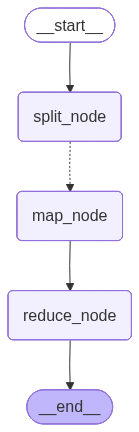

In [2]:
from IPython.display import Image, display

try:
    display(Image(mapreduce_graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass